# Step 5A: 듀얼 모멘텀 (Dual Momentum) 확장

## 개념 (Antonacci, 2014)

```
Step 1. 절대 모멘텀 (Absolute Momentum)
   → 각 종목의 12개월 수익률이 무위험수익률(T-bill)보다 높은가?
   → 낮으면: 현금(또는 채권)으로 편출 — 하락장 방어

Step 2. 상대 모멘텀 (Relative Momentum)
   → 편출 안 된 종목 중 횡단면 순위로 Q 생성 (Step5 기존 방식)
   → BL에 Q 입력
```

## Step5와 차이점
| 항목 | Step5 (기본) | Step5A (듀얼 모멘텀) |
|------|------------|--------------------|
| 편출 조건 | 없음 (항상 55종목 보유) | 절대 모멘텀 < T-bill → 비중 0 |
| Q 생성 | 전체 55종목 | 편출 제외 후 잔존 종목만 |
| 2020 코로나 | 급락 노출 | 절대 모멘텀 음수 종목 자동 편출 |

## 기대 효과
- 하락장에서 현금/채권 편출로 MDD 감소
- 모멘텀 크래시(급락 후 급반등) 시 일부 방어

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize
import warnings
import pickle
import yfinance as yf

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

BASE = Path('.')
DATA = BASE / 'data'
IMAGES = BASE / 'images'
CACHE = DATA / 'stock5_cache'

# Step5와 동일한 상수
TOP_N = 5
REBALANCE_FREQ = 21
UNIVERSE_UPDATE_FREQ = 252
ANALYSIS_START = '2016-01-01'
PRICE_START = '2013-01-01'
PRICE_END = '2025-12-31'
COV_WIN = 252
TAU = 1 / 252
LAM = 2.5
ABS_MOMENTUM_WIN = 252  # 절대 모멘텀: 12개월 수익률 비교

print('Step 5A: 듀얼 모멘텀 확장 — 준비 완료')

Step 5A: 듀얼 모멘텀 확장 — 준비 완료


## 셀 2: Step5 데이터/함수 재사용

Step5와 동일한 데이터, 함수 재정의

In [ ]:
import io, requests

def fetch_sp500_snapshot(cache_path=None):
    cache_path = cache_path or (CACHE / 'sp500_snapshot.pkl')
    if cache_path.exists():
        with open(cache_path, 'rb') as f:
            return pickle.load(f)
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    headers = {'User-Agent': 'Mozilla/5.0 (compatible; research-bot)'}
    resp = requests.get(url, headers=headers, timeout=30)
    tables = pd.read_html(io.StringIO(resp.text))
    df = tables[0].copy()
    df.columns = [str(c).strip() for c in df.columns]

    # 동적 컬럼명 탐색
    ticker_col = next(c for c in df.columns if 'symbol' in c.lower() or 'ticker' in c.lower())
    sector_col = next(
        c for c in df.columns
        if 'gics sector' in c.lower() or ('sector' in c.lower() and 'sub' not in c.lower())
    )
    
    result = df[[ticker_col, sector_col]].rename(
        columns={ticker_col: 'ticker', sector_col: 'sector'}
    ).copy()
    result['ticker'] = result['ticker'].str.replace('.', '-', regex=False).str.strip()
    result = result.dropna().reset_index(drop=True)
    with open(cache_path, 'wb') as f:
        pickle.dump(result, f)
    print(f'S&P 500 종목 {len(result)}개 수집')
    return result


def fetch_sp500_changes(cache_path=None):
    cache_path = cache_path or (CACHE / 'sp500_changes.pkl')
    if cache_path.exists():
        with open(cache_path, 'rb') as f:
            return pickle.load(f)
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    headers = {'User-Agent': 'Mozilla/5.0 (compatible; research-bot)'}
    resp = requests.get(url, headers=headers, timeout=30)
    tables = pd.read_html(io.StringIO(resp.text))
    raw = tables[1].copy()
    raw.columns = [str(c).strip() for c in raw.columns]
    date_col = raw.columns[0]
    def find_col(df, keywords):
        for c in df.columns:
            if any(k.lower() in str(c).lower() for k in keywords): return c
        return None
    added_col   = find_col(raw, ['added', 'add']) or raw.columns[1]
    removed_col = find_col(raw, ['removed', 'remove']) or raw.columns[3]
    changes = pd.DataFrame({
        'date':    pd.to_datetime(raw[date_col], errors='coerce'),
        'added':   raw[added_col].astype(str).str.strip().str.replace('.', '-', regex=False),
        'removed': raw[removed_col].astype(str).str.strip().str.replace('.', '-', regex=False),
    }).dropna(subset=['date'])
    changes['added']   = changes['added'].replace({'nan': None, 'NaN': None, '': None})
    changes['removed'] = changes['removed'].replace({'nan': None, 'NaN': None, '': None})
    changes = changes.sort_values('date').reset_index(drop=True)
    with open(cache_path, 'wb') as f:
        pickle.dump(changes, f)
    return changes


def filter_pool_by_date(snapshot_df, changes_df, target_date):
    target_dt   = pd.Timestamp(target_date)
    added_after = set(
        changes_df.loc[
            (changes_df['date'] > target_dt) & changes_df['added'].notna(), 'added'
        ].dropna()
    )
    filtered_df = snapshot_df[~snapshot_df['ticker'].isin(added_after)].reset_index(drop=True)
    excluded    = sorted(set(snapshot_df['ticker']) & added_after)
    return filtered_df, excluded


sp500_snapshot = fetch_sp500_snapshot()
sp500_changes  = fetch_sp500_changes()
print(f'후보 풀: {len(sp500_snapshot)}개 종목, {sp500_snapshot["sector"].nunique()}개 섹터')


# ── 채권/대안 ETF (통합 BL) ──────────────────────────────────────────────
# Asness et al. 2013: 모멘텀은 주식·채권·원자재 모두 동일 공식 적용 가능
BOND_TICKERS = ['TLT', 'SHY', 'TIP', 'AGG', 'GLD', 'DBC']

bond_cache = CACHE / 'bond_prices.pkl'
if bond_cache.exists():
    with open(bond_cache, 'rb') as f:
        bond_prices = pickle.load(f)
    print(f'채권 데이터 로드: {bond_prices.shape} (캐시)')
else:
    print('채권 ETF 데이터 다운로드 중...')
    raw = yf.download(BOND_TICKERS, start=PRICE_START, end=PRICE_END,
                      auto_adjust=True)['Close']
    if isinstance(raw, pd.Series):
        raw = raw.to_frame()
    bond_prices = raw[BOND_TICKERS].dropna(how='all').ffill()
    with open(bond_cache, 'wb') as f:
        pickle.dump(bond_prices, f)
    print(f'채권 데이터 저장: {bond_prices.shape}')

# ── prices_combined: 주식 + 채권/대안 통합 가격 ──────────────────────────
prices_combined = prices.copy()
for bt in BOND_TICKERS:
    if bt in bond_prices.columns:
        prices_combined[bt] = bond_prices[bt]
prices_combined = prices_combined.ffill()
print(f'통합 가격 데이터: {prices_combined.shape}')


후보 풀: 503개 종목, 11개 섹터
채권 데이터 로드: (3269, 6) (캐시)


NameError: name 'prices' is not defined

In [ ]:
# Step5A 공통 함수 (Step5와 동일 구조)

def select_universe_by_mcap(price_snap, shares_dict, pool_df, top_n=5):
    sector_map = {}
    mcap_map   = {}
    for sector, grp in pool_df.groupby('sector'):
        avail = [
            t for t in grp['ticker']
            if t in price_snap.index
            and pd.notna(price_snap.get(t, np.nan))
            and shares_dict.get(t, 0) > 0
        ]
        if not avail: continue
        mcap     = {t: price_snap[t] * shares_dict[t] for t in avail}
        selected = sorted(mcap.items(), key=lambda x: x[1], reverse=True)[:top_n]
        sector_map[sector] = [t for t, _ in selected]
        for t, m in selected: mcap_map[t] = m
    universe   = [t for ts in sector_map.values() for t in ts]
    total_mcap = sum(mcap_map.values()) or 1
    w_mkt      = pd.Series({t: mcap_map[t] / total_mcap for t in universe})
    return universe, sector_map, w_mkt


def compute_prior_risk_parity(cov, lam=2.5):
    """Risk Parity Prior (Maillard et al. 2010): 채권·주식 통합 시 사용"""
    n  = cov.shape[0]
    s  = np.sqrt(np.diag(cov))
    w0 = (1.0 / s) / (1.0 / s).sum()
    def erc_obj(w):
        pv = float(w @ cov @ w)
        if pv < 1e-12: return 1e10
        rc = w * (cov @ w) / np.sqrt(pv)
        return float(np.sum((rc - np.sqrt(pv)/n)**2))
    res = minimize(erc_obj, w0, method='SLSQP',
                   bounds=[(1e-4, 1.0)]*n,
                   constraints=[{'type': 'eq', 'fun': lambda w: w.sum()-1}],
                   options={'ftol': 1e-10, 'maxiter': 1000})
    w_rp = np.clip(res.x if res.success else w0, 0, 1)
    w_rp /= w_rp.sum()
    return pd.Series(lam * cov @ w_rp, index=range(n))


def compute_momentum_Q(prices_window, windows=(126, 189, 252)):
    log_p = np.log(prices_window)
    qs = []
    for w in windows:
        if len(log_p) > w:
            qs.append((log_p.iloc[-1] - log_p.iloc[-(w+1)]) / w * 252)
    return pd.concat(qs, axis=1).mean(axis=1) if qs else pd.Series(0.0, index=prices_window.columns)


def compute_omega_idzorek(Q, cov, tau=1/252, c_min=0.10, c_max=0.90):
    q = Q.values
    z = (q - q.mean()) / (q.std() + 1e-8)
    sig = 1 / (1 + np.exp(-np.abs(z)))
    confidence = c_min + (c_max - c_min) * (sig - 0.5) / 0.5
    confidence = np.clip(confidence, c_min, c_max)
    omega_diag = ((1 - confidence) / confidence) * tau * np.diag(cov)
    return np.diag(omega_diag), confidence


def black_litterman(pi, cov, Q, omega, tau=1/252):
    P   = np.eye(len(Q))
    tS  = tau * cov
    tSi = np.linalg.inv(tS + np.eye(len(Q)) * 1e-8)
    Oi  = np.linalg.inv(omega + np.eye(len(Q)) * 1e-8)
    M   = np.linalg.inv(tSi + P.T @ Oi @ P)
    mu_bl = M @ (tSi @ pi.values + P.T @ Oi @ Q.values)
    sigma_bl = cov + M
    return pd.Series(mu_bl, index=Q.index), sigma_bl


def mvo_optimize_unified(mu, cov, gamma, equity_tickers, bond_tickers,
                          max_equity_weight, max_sector, sector_map,
                          max_bond_total, max_single_bond):
    """통합 MVO: 주식 + 채권/대안 ETF (프로파일별 비중 제약)"""
    all_tickers = list(equity_tickers) + list(bond_tickers)
    n = len(all_tickers)
    mu_arr  = mu.reindex(all_tickers).fillna(0).values
    eq_idx  = list(range(len(equity_tickers)))
    bnd_idx = list(range(len(equity_tickers), n))

    def neg_utility(w):
        return -(w @ mu_arr - (gamma / 2) * w @ cov @ w)

    constraints = [
        {'type': 'eq',   'fun': lambda w: w.sum() - 1.0},
        {'type': 'ineq', 'fun': lambda w: max_bond_total - w[bnd_idx].sum()},
    ]
    if sector_map:
        for sector, s_tickers in sector_map.items():
            idx = [eq_idx[list(equity_tickers).index(t)]
                   for t in s_tickers if t in list(equity_tickers)]
            if idx:
                constraints.append({
                    'type': 'ineq',
                    'fun': lambda w, i=idx: max_sector - sum(w[j] for j in i)
                })

    bounds = ([(0.0, max_equity_weight)] * len(equity_tickers) +
              [(0.0, max_single_bond)]   * len(bond_tickers))

    res = minimize(neg_utility, np.ones(n) / n, method='SLSQP',
                   bounds=bounds, constraints=constraints,
                   options={'ftol': 1e-9, 'maxiter': 1000})
    w = np.clip(res.x if res.success else np.ones(n)/n, 0, 1)
    return pd.Series(w / w.sum(), index=all_tickers)


# ── 리스크 프로파일 (채권 비중 제약 포함) ─────────────────────────────────
PROFILES = {
    'Aggressive':   {'gamma': 2, 'max_equity_weight': 0.15, 'max_sector': 0.50,
                     'max_bond_total': 0.20, 'max_single_bond': 0.12},
    'Neutral':      {'gamma': 5, 'max_equity_weight': 0.08, 'max_sector': 0.35,
                     'max_bond_total': 0.35, 'max_single_bond': 0.12},
    'Conservative': {'gamma': 8, 'max_equity_weight': 0.05, 'max_sector': 0.25,
                     'max_bond_total': 0.55, 'max_single_bond': 0.20},
}

print('공통 함수 정의 완료 (Risk Parity Prior + 통합 MVO)')
print(f'{"프로파일":15s} {"γ":>4s} {"max_eq_w":>9s} {"max_bond":>9s}')
for name, p in PROFILES.items():
    print(f'{name:15s} {p["gamma"]:>4} {p["max_equity_weight"]:>9.0%} {p["max_bond_total"]:>9.0%}')


함수 정의 완료


## 셀 3: 듀얼 모멘텀 핵심 함수

절대 모멘텀 필터: 종목의 12개월 수익률 > T-bill 수익률이면 보유, 아니면 편출

In [ ]:
def get_tbill_rate_approx(date, default_rate=0.02):
    """T-bill 연간 수익률 근사 (SHY ETF 12개월 수익률 사용)"""
    try:
        shy_cache = CACHE / 'shy_prices.pkl'
        if shy_cache.exists():
            with open(shy_cache, 'rb') as f:
                shy = pickle.load(f)
        else:
            shy = yf.download('SHY', start='2013-01-01', end=PRICE_END,
                              auto_adjust=True)['Close'].squeeze()
            with open(shy_cache, 'wb') as f:
                pickle.dump(shy, f)
        if date in shy.index and len(shy.loc[:date]) > 252:
            p0 = shy.loc[:date].iloc[-253]
            p1 = shy.loc[:date].iloc[-1]
            return p1 / p0 - 1
    except Exception:
        pass
    return default_rate


def apply_absolute_momentum_filter(universe, prices_win, date, threshold_tbill=None):
    """절대 모멘텀 필터: 12개월 수익률 < T-bill → 편출 (전 자산 공통 적용)"""
    if threshold_tbill is None:
        threshold_tbill = get_tbill_rate_approx(date)
    active, excluded = [], []
    for t in universe:
        if t not in prices_win.columns:
            excluded.append(t)
            continue
        pw = prices_win[t].dropna()
        if len(pw) < ABS_MOMENTUM_WIN + 1:
            active.append(t)
            continue
        ret_12m = pw.iloc[-1] / pw.iloc[-(ABS_MOMENTUM_WIN + 1)] - 1
        if ret_12m > threshold_tbill:
            active.append(t)
        else:
            excluded.append(t)
    return active, excluded


# 테스트 (최신 시점 기준 combined universe)
test_date = prices_combined.index[-1]
latest_pool, _ = filter_pool_by_date(sp500_snapshot, sp500_changes, test_date)
test_eq_univ, test_sm, _ = select_universe_by_mcap(
    prices.iloc[-1], shares_dict, latest_pool, TOP_N
)
test_combined = list(test_eq_univ) + [b for b in BOND_TICKERS if b not in test_eq_univ]

active, excluded = apply_absolute_momentum_filter(
    test_combined, prices_combined, test_date
)
print(f'최신 시점 절대 모멘텀 필터 (주식 + 채권/대안):')
print(f'  전체: {len(test_combined)}개  →  보유: {len(active)}개, 편출: {len(excluded)}개')
bond_excluded = [t for t in excluded if t in BOND_TICKERS]
print(f'  채권/대안 편출: {bond_excluded if bond_excluded else "없음"}')


[*********************100%***********************]  1 of 1 completed

최신 시점 절대 모멘텀 필터 결과:
  보유 종목: 40개
  편출 종목: 15개 — ['UNH', 'AMZN', 'TSLA', 'HD', 'NFLX', 'DIS', 'COP', 'EOG', 'COST', 'PG', 'LIN', 'SHW', 'AMT', 'EQIX', 'SRE']


## 셀 4: Walk-Forward 백테스트 (듀얼 모멘텀)

In [ ]:
analysis_days = prices_combined.loc[ANALYSIS_START:].index
n_days = len(analysis_days)

start_snap = prices.loc[analysis_days[0]]
init_pool, _ = filter_pool_by_date(sp500_snapshot, sp500_changes, analysis_days[0])
current_eq_univ, current_sector_map, _ = select_universe_by_mcap(
    start_snap, shares_dict, init_pool, TOP_N
)

def build_combined_universe(eq_univ, bond_tickers):
    return list(eq_univ) + [b for b in bond_tickers if b not in eq_univ]

current_universe = build_combined_universe(current_eq_univ, BOND_TICKERS)
n_all = len(current_universe)

current_weights  = {p: pd.Series(1.0/n_all, index=current_universe) for p in PROFILES}
current_weights['EqualWeight'] = pd.Series(1.0/n_all, index=current_universe)
current_excluded = []

port_values    = {p: [1.0] for p in list(PROFILES.keys()) + ['EqualWeight']}
exclusion_rate = []

print(f'분석 기간: {analysis_days[0].date()} ~ {analysis_days[-1].date()}')
print(f'전략: 듀얼 모멘텀 (절대 모멘텀 편출 + 상대 모멘텀 BL) — 주식 + 채권/대안')
print(f'초기 유니버스: 주식 {len(current_eq_univ)} + 채권/대안 {len(BOND_TICKERS)} = {n_all}개')

for i, date in enumerate(analysis_days[1:], 1):
    prev_date = analysis_days[i - 1]

    # 일별 수익률
    ret = {}
    for t in current_universe:
        if t in prices_combined.columns:
            p0 = prices_combined.at[prev_date, t] if prev_date in prices_combined.index else np.nan
            p1 = prices_combined.at[date, t]      if date      in prices_combined.index else np.nan
            ret[t] = (p1/p0 - 1) if (pd.notna(p0) and pd.notna(p1) and p0 > 0) else 0.0
        else:
            ret[t] = 0.0
    for t in current_excluded:
        ret[t] = 0.0  # 편출 종목 수익 0 (현금 보유)

    # 포트폴리오 가치 업데이트
    for p in PROFILES:
        w = current_weights[p]
        port_ret = sum(w.get(t, 0) * ret.get(t, 0) for t in current_universe)
        port_values[p].append(port_values[p][-1] * (1 + port_ret))

    ew_active = [t for t in current_universe if t not in current_excluded]
    ew_ret = np.mean([ret.get(t, 0) for t in ew_active]) if ew_active else 0
    port_values['EqualWeight'].append(port_values['EqualWeight'][-1] * (1 + ew_ret))

    # 연간 유니버스 갱신
    if i % UNIVERSE_UPDATE_FREQ == 0:
        year_pool, _ = filter_pool_by_date(sp500_snapshot, sp500_changes, date)
        new_eq_univ, new_sector_map, _ = select_universe_by_mcap(
            prices.loc[date], shares_dict, year_pool, TOP_N
        )
        current_eq_univ    = new_eq_univ
        current_sector_map = new_sector_map
        current_universe   = build_combined_universe(current_eq_univ, BOND_TICKERS)
        n_all = len(current_universe)
        for p in list(PROFILES.keys()) + ['EqualWeight']:
            current_weights[p] = pd.Series(1.0/n_all, index=current_universe)
        print(f'  [{date.date()}] 유니버스 갱신: 주식 {len(current_eq_univ)}+채권 {len(BOND_TICKERS)} = {n_all}개')

    # 21일마다 BL 리밸런싱 + 절대 모멘텀 편출 갱신
    if i % REBALANCE_FREQ == 0:
        prices_win = prices_combined.loc[:date, current_universe]
        if len(prices_win) < COV_WIN + 253:
            continue

        # 1단계: 절대 모멘텀 필터 (전 자산)
        active_tickers, current_excluded = apply_absolute_momentum_filter(
            current_universe, prices_win, date
        )
        exclusion_rate.append(len(current_excluded) / len(current_universe))

        if len(active_tickers) < 5:
            for p in PROFILES:
                n_a = max(len(active_tickers), 1)
                current_weights[p] = pd.Series(
                    {t: (1.0/n_a if t in active_tickers else 0.0) for t in current_universe}
                )
            continue

        # 2단계: 공분산 계산
        active_window = prices_win[active_tickers]
        recent = active_window.iloc[-COV_WIN:]
        log_r  = np.log(recent / recent.shift(1)).dropna()
        if log_r.shape[0] < 60:
            continue

        lw = LedoitWolf()
        lw.fit(log_r)
        cov = lw.covariance_ * 252

        # 3단계: Risk Parity Prior + Momentum Q (전 자산 동일)
        pi_raw = compute_prior_risk_parity(cov, LAM)
        pi = pd.Series(pi_raw.values, index=active_tickers)
        Q  = compute_momentum_Q(active_window, (126, 189, 252)).reindex(active_tickers).fillna(0)
        omega, _ = compute_omega_idzorek(Q, cov, TAU)
        mu_bl, sigma_bl = black_litterman(pi, cov, Q, omega, TAU)

        # 4단계: MVO (프로파일별 제약)
        active_eq   = [t for t in current_eq_univ   if t in active_tickers]
        active_bond = [t for t in BOND_TICKERS       if t in active_tickers]
        active_sm   = {s: [t for t in ts if t in active_tickers]
                       for s, ts in current_sector_map.items()}
        active_sm   = {s: ts for s, ts in active_sm.items() if ts}

        for p, prof in PROFILES.items():
            if not active_eq:
                current_weights[p] = pd.Series(0.0, index=current_universe)
                continue
            w_active = mvo_optimize_unified(
                mu_bl, sigma_bl, prof['gamma'],
                equity_tickers    = active_eq,
                bond_tickers      = active_bond,
                max_equity_weight = prof['max_equity_weight'],
                max_sector        = prof['max_sector'],
                sector_map        = active_sm,
                max_bond_total    = prof['max_bond_total'],
                max_single_bond   = prof['max_single_bond'],
            )
            w_full = pd.Series(0.0, index=current_universe)
            w_full[active_tickers] = w_active
            if w_full.sum() > 0:
                w_full = w_full / w_full.sum()
            current_weights[p] = w_full

print('\n백테스트 완료!')
avg_excl = np.mean(exclusion_rate) * 100 if exclusion_rate else 0
print(f'평균 편출 비율: {avg_excl:.1f}%')


분석 기간: 2016-01-04 ~ 2025-12-30
전략: 듀얼 모멘텀 (절대 모멘텀 편출 + 상대 모멘텀 Q)
  [2017-01-03] 유니버스 갱신: 55종목
  [2018-01-03] 유니버스 갱신: 55종목
  [2019-01-04] 유니버스 갱신: 55종목
  [2020-01-06] 유니버스 갱신: 55종목
  [2021-01-05] 유니버스 갱신: 55종목
  [2022-01-04] 유니버스 갱신: 55종목
  [2023-01-05] 유니버스 갱신: 55종목
  [2024-01-08] 유니버스 갱신: 55종목
  [2025-01-08] 유니버스 갱신: 55종목

백테스트 완료!
평균 편출 비율: 29.3%


## 셀 5: 성능 비교 (Step5 기본 vs 듀얼 모멘텀)

In [ ]:
def compute_metrics(values, dates_list):
    vals = np.array(values)
    rets = np.diff(vals) / vals[:-1]
    n_years = (pd.Timestamp(dates_list[-1]) - pd.Timestamp(dates_list[0])).days / 365.25
    total_ret = vals[-1] / vals[0] - 1
    ann_ret = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else 0
    ann_vol = rets.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    running_max = np.maximum.accumulate(vals)
    mdd = ((vals - running_max) / running_max).min()
    down = rets[rets < 0]
    sortino = ann_ret / (down.std() * np.sqrt(252)) if len(down) > 0 else 0
    calmar = ann_ret / abs(mdd) if mdd != 0 else 0
    return {'ann_return': ann_ret, 'ann_vol': ann_vol, 'sharpe': sharpe,
            'mdd': mdd, 'sortino': sortino, 'calmar': calmar}


dates = list(analysis_days)
metrics = {}
for p in list(PROFILES.keys()) + ['EqualWeight']:
    metrics[f'DualMom_{p}'] = compute_metrics(port_values[p], dates)

# SPY B&H
with open(CACHE / 'spy_prices.pkl', 'rb') as f:
    spy_raw = pickle.load(f)
spy_aligned = spy_raw.loc[ANALYSIS_START:]
spy_norm = (spy_aligned / spy_aligned.iloc[0]).values
metrics['SPY_BnH'] = compute_metrics(spy_norm, list(spy_aligned.index))

print('=== 듀얼 모멘텀 성능 요약 ===')
header = f'{"전략":25s} {"연수익률":>10s} {"변동성":>10s} {"Sharpe":>8s} {"MDD":>10s} {"Sortino":>10s}'
print(header)
print('-' * 75)
for name, m in metrics.items():
    print(f'{name:25s} {m["ann_return"]:>10.2%} {m["ann_vol"]:>10.2%} '
          f'{m["sharpe"]:>8.3f} {m["mdd"]:>10.2%} {m["sortino"]:>10.3f}')

pd.DataFrame(metrics).T.to_csv(DATA / 'step5a_dualmom_metrics.csv')
print('\n저장: data/step5a_dualmom_metrics.csv')

=== 듀얼 모멘텀 성능 요약 ===
전략                              연수익률        변동성   Sharpe        MDD    Sortino
---------------------------------------------------------------------------
DualMom_Aggressive            22.07%     25.27%    0.873    -34.18%      1.138
DualMom_Neutral               17.53%     20.56%    0.853    -33.49%      1.063
DualMom_Conservative          15.15%     18.10%    0.837    -32.10%      1.021
DualMom_EqualWeight           14.51%     16.51%    0.879    -31.21%      1.047
SPY_BnH                       14.98%     18.01%    0.832    -33.72%      0.999

저장: data/step5a_dualmom_metrics.csv


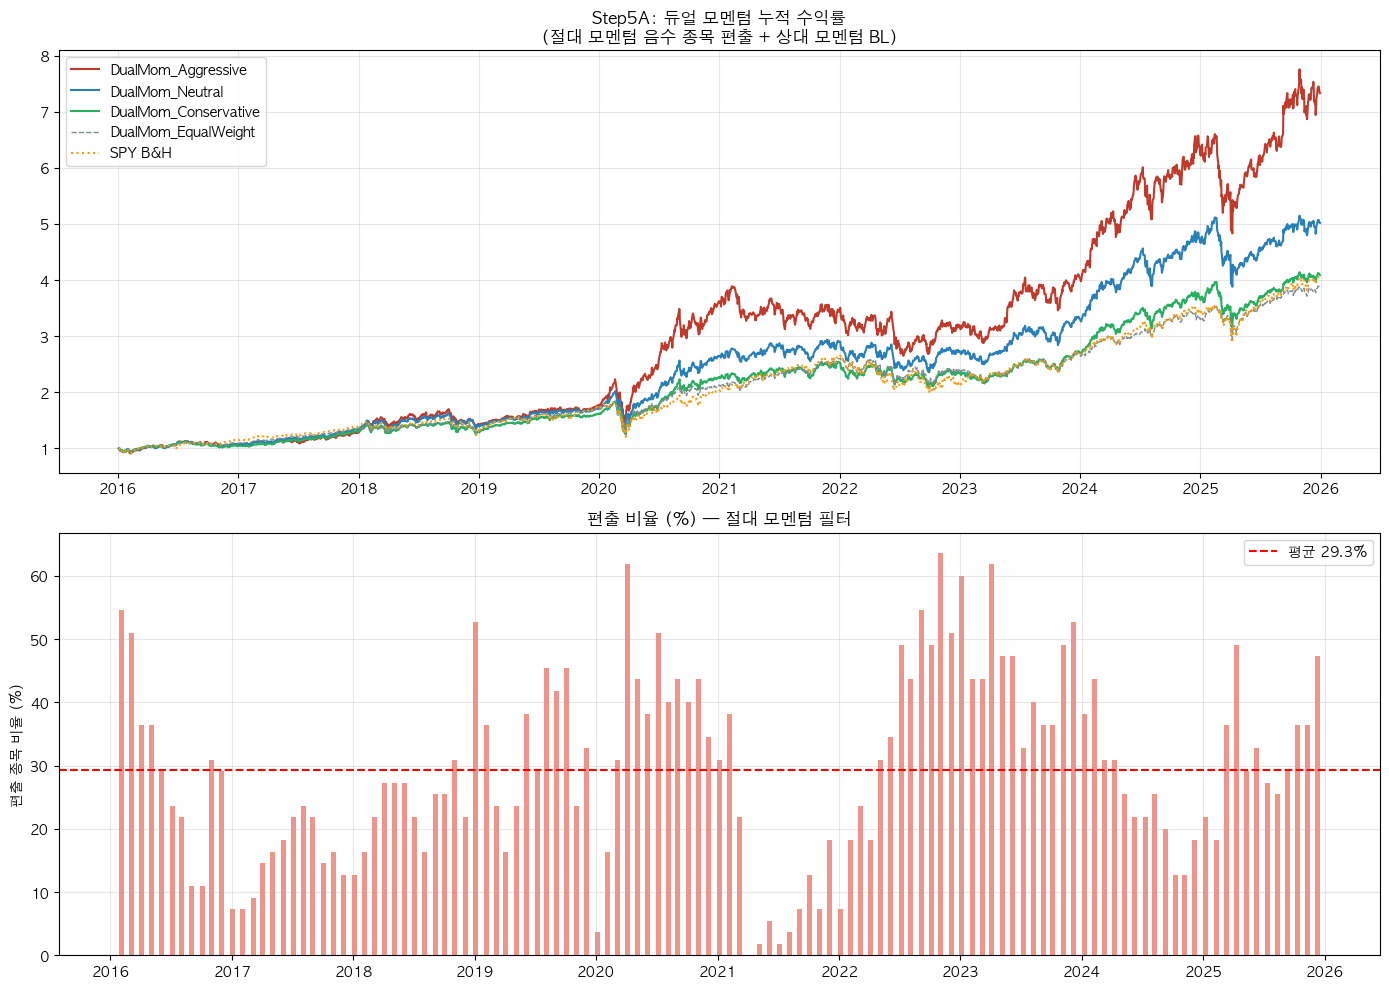

저장: images/step5a_dualmom.png


In [ ]:
# 시각화: 누적 수익률 + 편출 비율 히스토그램
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

COLORS = {
    'DualMom_Aggressive': '#c0392b',
    'DualMom_Neutral': '#2980b9',
    'DualMom_Conservative': '#27ae60',
    'DualMom_EqualWeight': '#7f8c8d',
    'SPY_BnH': '#f39c12'
}

ax = axes[0]
for p in PROFILES:
    ax.plot(dates, port_values[p], label=f'DualMom_{p}', color=COLORS.get(f'DualMom_{p}', 'gray'), linewidth=1.5)
ax.plot(dates, port_values['EqualWeight'], label='DualMom_EqualWeight',
        color=COLORS['DualMom_EqualWeight'], linewidth=1, linestyle='--')
ax.plot(list(spy_aligned.index), spy_norm, label='SPY B&H',
        color=COLORS['SPY_BnH'], linewidth=1.5, linestyle=':')
ax.set_title('Step5A: 듀얼 모멘텀 누적 수익률\n(절대 모멘텀 음수 종목 편출 + 상대 모멘텀 BL)')
ax.legend()
ax.grid(True, alpha=0.3)

# 편출 비율 시계열
ax2 = axes[1]
if exclusion_rate:
    rebal_dates = [analysis_days[i * REBALANCE_FREQ] for i in range(1, len(exclusion_rate)+1)
                   if i * REBALANCE_FREQ < len(analysis_days)]
    plot_len = min(len(rebal_dates), len(exclusion_rate))
    ax2.bar(rebal_dates[:plot_len], [r*100 for r in exclusion_rate[:plot_len]],
            color='#e74c3c', alpha=0.6, width=15)
    ax2.set_title('편출 비율 (%) — 절대 모멘텀 필터')
    ax2.set_ylabel('편출 종목 비율 (%)')
    ax2.axhline(np.mean(exclusion_rate)*100, color='red', linestyle='--',
                label=f'평균 {np.mean(exclusion_rate)*100:.1f}%')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGES / 'step5a_dualmom.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: images/step5a_dualmom.png')